In [611]:
from platform import python_version

print(python_version())

3.12.7


In [612]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [613]:
#Import data source
pl = pd.read_csv("standings.csv")
pl.head()

,rank,team,win,loss,draw,goals,conceded,points,last5,top_scorer,keeper
0,1,Liverpool,25,4,8,85,40,83,W W L D L,Mohamed Salah,Alisson
1,2,Arsenal,19,4,14,67,33,71,W D L D W,Kai Havertz,David Raya
2,3,Manchester City,20,9,8,70,44,68,W W W D W,Erling Haaland,Ederson
3,4,Newcastle Utd,20,11,6,68,46,66,L W D W L,Alexander Isak,Nick Pope
4,5,Chelsea,19,9,9,63,43,66,W W W L W,Cole Palmer,Robert Sánchez


In [614]:
salary = pd.read_csv("team_salary.csv")
salary.head()

,team,players,weekly,annual
0,Manchester City,61,5211401,270992872
1,Manchester Utd,60,4668844,242779887
2,Chelsea,71,4443518,231062958
3,Arsenal,51,4373711,227432965
4,Liverpool,60,3325255,172913278


In [615]:
pl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   rank        20 non-null     int64 
 1   team        20 non-null     object
 2   win         20 non-null     int64 
 3   loss        20 non-null     int64 
 4   draw        20 non-null     int64 
 5   goals       20 non-null     int64 
 6   conceded    20 non-null     int64 
 7   points      20 non-null     int64 
 8   last5       20 non-null     object
 9   top_scorer  20 non-null     object
 10  keeper      20 non-null     object
dtypes: int64(7), object(4)
memory usage: 1.8+ KB


In [616]:
salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   team     20 non-null     object
 1   players  20 non-null     int64 
 2   weekly   20 non-null     int64 
 3   annual   20 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 772.0+ bytes


In [617]:
# Check for possible duplicated rows
pl.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
dtype: bool

In [618]:
salary.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
dtype: bool

In [619]:
# Check for possible missing data
pl.isnull()

,rank,team,win,loss,draw,goals,conceded,points,last5,top_scorer,keeper
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False


In [620]:
salary.isnull()

,team,players,weekly,annual
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,False
6,False,False,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


In [621]:
# Dropping statistics that do not impact analysis
pl.drop(columns=['last5','top_scorer','keeper'],axis=1, inplace=True)

In [622]:
print(pl)

    rank             team  win  loss  draw  goals  conceded  points
0      1        Liverpool   25     4     8     85        40      83
1      2          Arsenal   19     4    14     67        33      71
2      3  Manchester City   20     9     8     70        44      68
3      4    Newcastle Utd   20    11     6     68        46      66
4      5          Chelsea   19     9     9     63        43      66
5      6      Aston Villa   19     9     9     58        49      66
6      7  Nott'ham Forest   19    10     8     58        45      65
7      8         Brighton   15     9    13     62        58      58
8      9        Brentford   16    14     7     65        56      55
9     10           Fulham   15    13     9     54        52      54
10    11      Bournemouth   14    12    11     56        46      53
11    12   Crystal Palace   13    11    13     50        50      52
12    13          Everton   10    12    15     41        44      45
13    14           Wolves   12    20     5     5

In [623]:
salary.drop(columns=['weekly'],axis=1, inplace=True)

In [624]:
print(salary)

               team  players     annual
0   Manchester City       61  270992872
1    Manchester Utd       60  242779887
2           Chelsea       71  231062958
3           Arsenal       51  227432965
4         Liverpool       60  172913278
5       Aston Villa       68  144361995
6         Tottenham       66  140697102
7     Newcastle Utd       62  138637776
8          West Ham       54  121116085
9           Everton       54   95880658
10   Crystal Palace       63   93716625
11           Fulham       53   91831819
12   Leicester City       57   87817887
13  Nott'ham Forest       62   85235009
14         Brighton       71   83175683
15      Southampton       68   75217626
16      Bournemouth       56   73437533
17           Wolves       70   71448017
18        Brentford       57   55671515
19     Ipswich Town       56   45933362


In [625]:
# Ensuring team names match across the two datasets
pl['team'].unique()
salary['team'].unique()

array(['Manchester City', 'Manchester Utd', 'Chelsea', 'Arsenal',
       'Liverpool', 'Aston Villa', 'Tottenham', 'Newcastle Utd',
       'West Ham', 'Everton', 'Crystal Palace', 'Fulham',
       'Leicester City', "Nott'ham Forest", 'Brighton', 'Southampton',
       'Bournemouth', 'Wolves', 'Brentford', 'Ipswich Town'], dtype=object)

In [626]:
# Checking data type before merging datasets
pl.dtypes

rank         int64
team        object
win          int64
loss         int64
draw         int64
goals        int64
conceded     int64
points       int64
dtype: object

In [627]:
salary.dtypes

team       object
players     int64
annual      int64
dtype: object

In [628]:
# Creating a new variable to more easily analyse team performance
pl['goal_diff']=(pl['goals']-pl['conceded'])
print (pl)

    rank             team  win  loss  draw  goals  conceded  points  goal_diff
0      1        Liverpool   25     4     8     85        40      83         45
1      2          Arsenal   19     4    14     67        33      71         34
2      3  Manchester City   20     9     8     70        44      68         26
3      4    Newcastle Utd   20    11     6     68        46      66         22
4      5          Chelsea   19     9     9     63        43      66         20
5      6      Aston Villa   19     9     9     58        49      66          9
6      7  Nott'ham Forest   19    10     8     58        45      65         13
7      8         Brighton   15     9    13     62        58      58          4
8      9        Brentford   16    14     7     65        56      55          9
9     10           Fulham   15    13     9     54        52      54          2
10    11      Bournemouth   14    12    11     56        46      53         10
11    12   Crystal Palace   13    11    13     50   

In [629]:
# Merging the two datasets using outer join which merges all columns 
results=pd.merge(pl, salary, on='team', how='outer', validate='1:1', indicator=True)

In [630]:
results = results.sort_values(by='rank')
display(results)

,rank,team,win,loss,draw,goals,conceded,points,goal_diff,players,annual,_merge
11,1,Liverpool,25,4,8,85,40,83,45,60,172913278,both
0,2,Arsenal,19,4,14,67,33,71,34,51,227432965,both
12,3,Manchester City,20,9,8,70,44,68,26,61,270992872,both
14,4,Newcastle Utd,20,11,6,68,46,66,22,62,138637776,both
5,5,Chelsea,19,9,9,63,43,66,20,71,231062958,both
1,6,Aston Villa,19,9,9,58,49,66,9,68,144361995,both
15,7,Nott'ham Forest,19,10,8,58,45,65,13,62,85235009,both
4,8,Brighton,15,9,13,62,58,58,4,71,83175683,both
3,9,Brentford,16,14,7,65,56,55,9,57,55671515,both
8,10,Fulham,15,13,9,54,52,54,2,53,91831819,both


In [631]:
results = results.sort_values('rank').set_index('rank')
display(results)

,team,win,loss,draw,goals,conceded,points,goal_diff,players,annual,_merge
rank,,,,,,,,,,,
1,Liverpool,25,4,8,85,40,83,45,60,172913278,both
2,Arsenal,19,4,14,67,33,71,34,51,227432965,both
3,Manchester City,20,9,8,70,44,68,26,61,270992872,both
4,Newcastle Utd,20,11,6,68,46,66,22,62,138637776,both
5,Chelsea,19,9,9,63,43,66,20,71,231062958,both
6,Aston Villa,19,9,9,58,49,66,9,68,144361995,both
7,Nott'ham Forest,19,10,8,58,45,65,13,62,85235009,both
8,Brighton,15,9,13,62,58,58,4,71,83175683,both
9,Brentford,16,14,7,65,56,55,9,57,55671515,both


In [632]:
# Post merge checklist for missing data
print(results['_merge'].value_counts())

_merge
both          20
left_only      0
right_only     0
Name: count, dtype: int64


In [633]:
print("\nMissing values after merge:")
print(results.isna().sum())


Missing values after merge:
team         0
win          0
loss         0
draw         0
goals        0
conceded     0
points       0
goal_diff    0
players      0
annual       0
_merge       0
dtype: int64


In [634]:
# Log wages taking into account diminishing return of wages for big and small clubs  
results['log_wages'] = np.log(results['annual'])
pd.options.display.float_format = '{:.3f}'.format
print(results['log_wages'])

rank
1    18.968
2    19.242
3    19.418
4    18.747
5    19.258
6    18.788
7    18.261
8    18.236
9    17.835
10   18.335
11   18.112
12   18.356
13   18.379
14   18.084
15   18.612
16   19.308
17   18.762
18   18.291
19   17.643
20   18.136
Name: log_wages, dtype: float64


In [635]:
# Calculating wage cost per point scored across the league
results['wage_per_point'] = results['annual']/results['points']
pd.options.display.float_format = '{:,.0f}'.format
print(results['wage_per_point'])

rank
1    2,083,293
2    3,203,281
3    3,985,189
4    2,100,572
5    3,500,954
6    2,187,303
7    1,311,308
8    1,434,064
9    1,012,209
10   1,700,589
11   1,385,614
12   1,802,243
13   2,130,681
14   1,742,635
15   3,027,902
16   6,225,125
17   3,702,555
18   3,512,715
19   2,087,880
20   6,268,136
Name: wage_per_point, dtype: float64


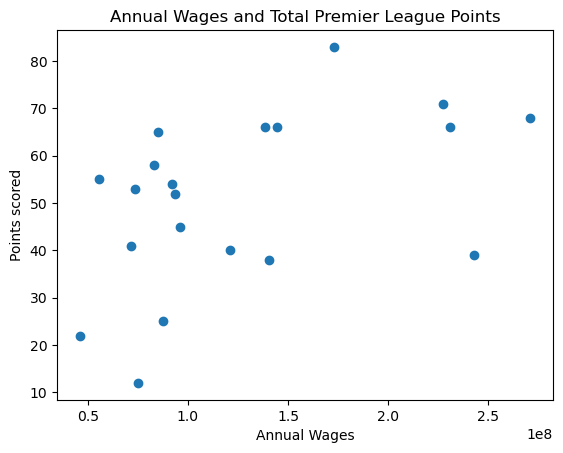

In [636]:
# Scatter graph of annual wages and points scored
plt.scatter(results['annual'], results['points'])
plt.xlabel('Annual Wages')
plt.ylabel('Points scored')
plt.title('Annual Wages and Total Premier League Points')
plt.show()

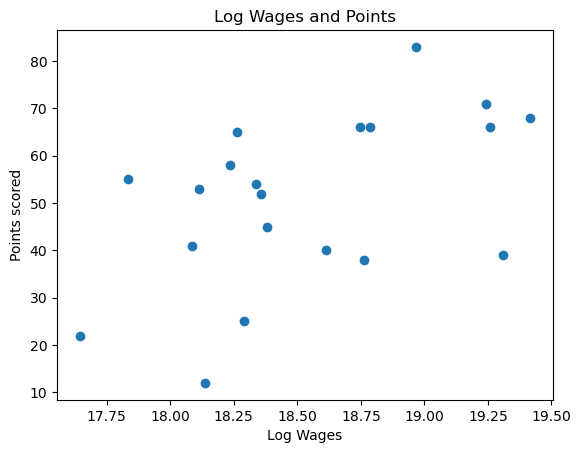

In [637]:
# Scatter graph of Log wages and points scored
plt.scatter(results['log_wages'], results['points'])
plt.xlabel('Log Wages')
plt.ylabel('Points scored')
plt.title('Log Wages and Points')
plt.show()

In [638]:
import statsmodels.api as sm
import seaborn as sns

In [639]:
# Relationship between LOG wage and points earned 
x = results['log_wages'].tolist()  
y = results['points'].tolist()
x = sm.add_constant(x)
model1 = sm.OLS(y,x).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     6.570
Date:                Fri, 01 May 2026   Prob (F-statistic):             0.0196
Time:                        14:09:44   Log-Likelihood:                -82.747
No. Observations:                  20   AIC:                             169.5
Df Residuals:                      18   BIC:                             171.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -291.9565    133.827     -2.182      0.0

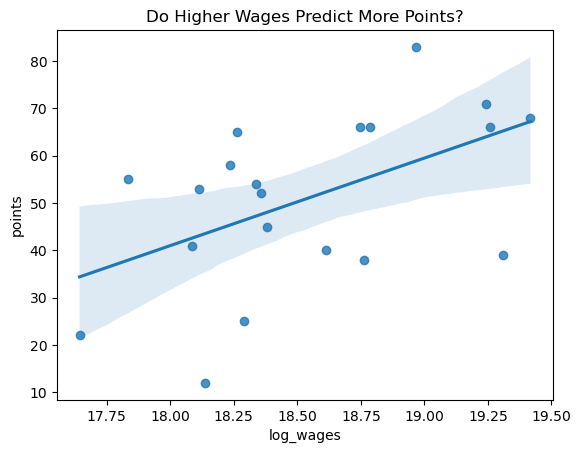

In [640]:
# Regression model 
sns.regplot(data=results, x='log_wages', y='points')
plt.title('Do Higher Wages Predict More Points?')
plt.show()

In [641]:
# Keeping the number of players controlled
x = results[['log_wages','players']]
x = sm.add_constant(x)
model2 = sm.OLS(y,x).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     3.111
Date:                Fri, 01 May 2026   Prob (F-statistic):             0.0706
Time:                        14:09:44   Log-Likelihood:                -82.739
No. Observations:                  20   AIC:                             171.5
Df Residuals:                      17   BIC:                             174.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -288.9371    140.325     -2.059      0.0

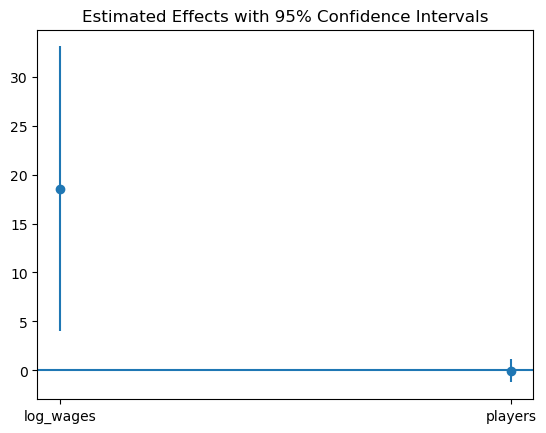

In [642]:
# Coefficient plot
coef = model2.params[1:]
se = model2.bse[1:]
plt.errorbar(coef.index, coef.values, yerr=1.96*se, fmt='o')
plt.axhline(0)
plt.title('Estimated Effects with 95% Confidence Intervals')
plt.show()

In [643]:
# Wage per player 
results['wage_per_player'] = results['annual']/results['players']
results['log_wage_per_player'] = results['log_wages']/results['players']
x = results[['log_wage_per_player']]
x = sm.add_constant(x)
model3 = sm.OLS(results['points'],x).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                 points   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                 -0.038
Method:                 Least Squares   F-statistic:                    0.3010
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.590
Time:                        14:09:44   Log-Likelihood:                -85.692
No. Observations:                  20   AIC:                             175.4
Df Residuals:                      18   BIC:                             177.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  28.7129    

In [644]:
# Interaction effects 
results['wage_player_interaction'] = (results['log_wages'] * results['players'])
x = results[['log_wages', 'players', 'wage_player_interaction']]
x = sm.add_constant(x)
model4 = sm.OLS(y,x).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     1.961
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.161
Time:                        14:09:44   Log-Likelihood:                -82.727
No. Observations:                  20   AIC:                             173.5
Df Residuals:                      16   BIC:                             177.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [645]:
# Test for diminishing returns 
results['wages_sq'] = results['log_wages']**2
x = results[['log_wages','wages_sq']]
x = sm.add_constant(x)
model5 = sm.OLS(y,x).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     3.279
Date:                Fri, 01 May 2026   Prob (F-statistic):             0.0625
Time:                        14:09:44   Log-Likelihood:                -82.596
No. Observations:                  20   AIC:                             171.2
Df Residuals:                      17   BIC:                             174.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2861.4546   5056.324     -0.566      0.5

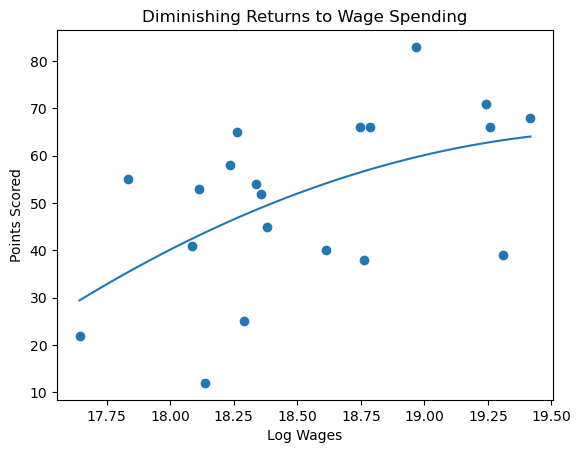

In [691]:
# Nonlinear model testing extent of diminishing returns 
x = np.linspace(results['log_wages'].min(), results['log_wages'].max(), 100)
b0,b1,b2 = model5.params
yhat = b0+b1*x+b2*(x**2)
plt.scatter(results['log_wages'], results['points'])
plt.plot(x,yhat)
plt.title('Diminishing Returns to Wage Spending')
plt.xlabel("Log Wages")
plt.ylabel("Points Scored")
plt.show()

In [647]:
# Predicted vs actual performance
results['predicted'] = model2.predict()
results['overperformance'] = results['points'] - results['predicted']
results[['team','overperformance']].sort_values(by='rank', ascending=True)

,team,overperformance
rank,,
1,Liverpool,24
2,Arsenal,6
3,Manchester City,1
4,Newcastle Utd,11
5,Chelsea,2
6,Aston Villa,11
7,Nott'ham Forest,19
8,Brighton,13
9,Brentford,17


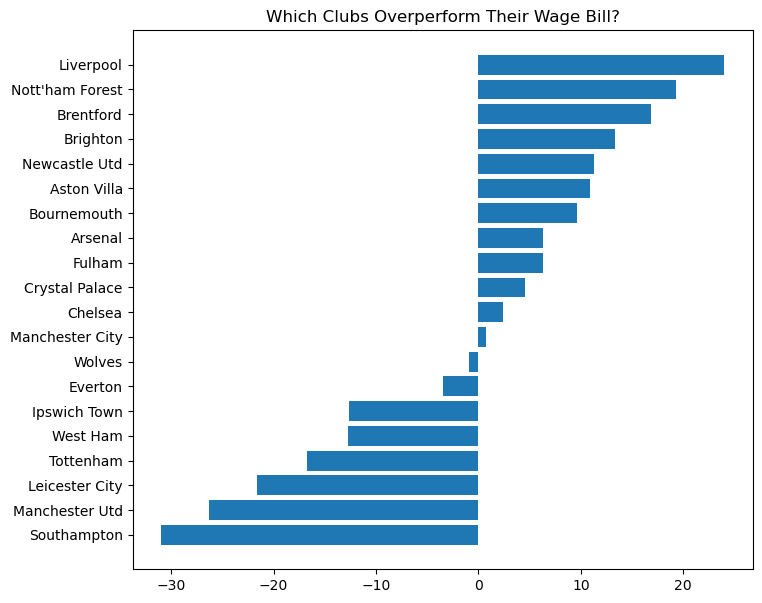

In [648]:
# Bar chart modelling overperformance relative to wage bill
over = results.sort_values('overperformance')
plt.figure(figsize=(8,7))
plt.barh(over['team'], over['overperformance'])
plt.title('Which Clubs Overperform Their Wage Bill?')
plt.show()

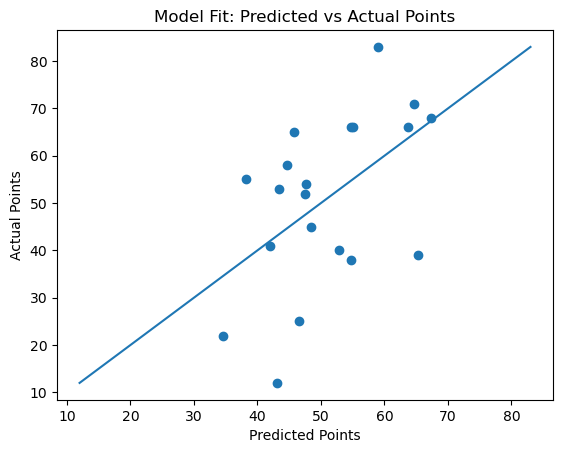

In [693]:
# Scatter plot for predicted vs actual points scored
plt.scatter(results['predicted'], results['points'])
plt.plot([results['points'].min(), results['points'].max()], [results['points'].min(), results['points'].max()])
plt.xlabel("Predicted Points")
plt.ylabel("Actual Points")
plt.title("Model Fit: Predicted vs Actual Points")
plt.show()

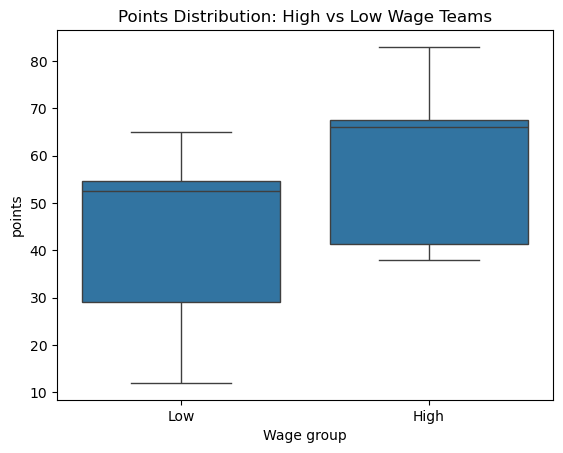

In [695]:
# Distribution of points between High and Low salary group
results['Wage group'] = pd.qcut(results['annual'], 2, labels=['Low','High'])
sns.boxplot(x='Wage group', y='points',data=results)
plt.title("Points Distribution: High vs Low Wage Teams")
plt.show()